# ***Ⅳ. 예측과 최적화***
# ***2. 손실함수***

## ***추세선과 오차***
- 여러 개의 추세선 중 어느 것이 주어진 데이터의 경향성을 더 잘 반영하는지 알아보려면 **오차(Error)** 를 계산해야 합니다
- 추세선이 실제 데이터를 얼마나 잘 설명하는지는 예측값과 실제값의 차이를 이용하여 판단할 수 있습니다


### ***예제 데이터***

| 입력값(x) | 실제값(y) |
| ------ | ------ |
| 1      | 1      |
| 2      | 7      |
| 3      | 9      |
| 4      | 8      |
| 5      | 13     |


### ***추세선 1***
$ f(x)=2x $

| 입력값(x) | 실제값(y) | 예측값 | 오차 |
| ------ | ------ | --- | -- |
| 1      | 1      | 2   | -1 |
| 2      | 7      | 4   | 3  |
| 3      | 9      | 6   | 3  |
| 4      | 8      | 8   | 0  |
| 5      | 13     | 10  | 3  |


### ***추세선 2***
$ f(x)=3x $

| 입력값(x) | 실제값(y) | 예측값 | 오차 |
| ------ | ------ | --- | -- |
| 1      | 1      | 3   | -2 |
| 2      | 7      | 6   | 1  |
| 3      | 9      | 9   | 0  |
| 4      | 8      | 12  | -4 |
| 5      | 13     | 15  | -2 |

## ***오차를 모두 합할 때 벌어지는 일***
- 오차를 단순히 모두 더하면 양수와 음수가 서로 상쇄될 수 있습니다
- 예를 들어 $ f(x)=3x $ 의 오차 합은 $ (-2)+1+0+(-4)+(-2)=-7 $
- 따라서 오차의 절댓값 또는 제곱을 이용한 함수를 사용합니다

## ***평균제곱오차(MSE)***
- 인공지능에서는 오차를 제곱하여 더한 값을 자주 사용합니다
- $ MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2 $

  $ y_i $: 실제값 \
  $ \hat y_i $ : 예측값 \
  $ n $ : 데이터의 수

- 오차가 작을수록 추세선이 데이터를 잘 설명한다고 볼 수 있습니다

In [1]:
import pandas as pd

# 데이터
x = [1, 2, 3, 4, 5]
y = [1, 7, 9, 8, 13]

# 추세선
pred_2x = [2*i for i in x]
pred_3x = [3*i for i in x]

# 오차
error_2x = [real - pred for real, pred in zip(y, pred_2x)]
error_3x = [real - pred for real, pred in zip(y, pred_3x)]

# 평균제곱오차(MSE)
mse_2x = sum(e**2 for e in error_2x) / len(error_2x)
mse_3x = sum(e**2 for e in error_3x) / len(error_3x)

print("f(x)=2x의 오차:", error_2x)
print("f(x)=2x의 MSE:", mse_2x)

print()

print("f(x)=3x의 오차:", error_3x)
print("f(x)=3x의 MSE:", mse_3x)

f(x)=2x의 오차: [-1, 3, 3, 0, 3]
f(x)=2x의 MSE: 5.6

f(x)=3x의 오차: [-2, 1, 0, -4, -2]
f(x)=3x의 MSE: 5.0


### ***실행 결과***

```text
f(x)=2x의 오차: [-1, 3, 3, 0, 3]
f(x)=2x의 MSE: 5.6

f(x)=3x의 오차: [-2, 1, 0, -4, -2]
f(x)=3x의 MSE: 5.0
```

## ***결론***

* (f(x)=2x) 의 MSE = 5.6
* (f(x)=3x) 의 MSE = 5.0

- 따라서 평균제곱오차가 더 작은 $ f(x)=3x $ 가 주어진 데이터를 더 잘 설명하는 추세선이라고 할 수 있습니다

- 인공지능은 학습 과정에서 이러한 오차 함수를 최소화하는 방향으로 모델의 규칙을 수정하며 최적의 추세선을 찾아갑니다

## ***평균절대오차(MAE)***
- 오차를 단순히 더하면 양수와 음수가 서로 상쇄되는 문제가 있어서 오차의 **절댓값**을 구한 뒤 평균을 계산하는 방법을 사용할 수 있습니다
- 이를 **평균절대오차(MAE)** 라고 합니다 \
\
$ MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat y_i| $

- $y_i$ : 실제값
- $\hat y_i$ : 예측값
- $n$ : 데이터의 수
- MAE도 MSE와 마찬가지로 작을수록 예측값이 실제값에 가깝다고 볼 수 있습니다

## ***MAE 계산 예시***
### ***추세선1***

$f(x)=2x$

- 오차: $ [-1,\ 3,\ 3,\ 0,\ 3] $
- 절댓값: $ [1,\ 3,\ 3,\ 0,\ 3] $
- MAE는 아래와 같이 구합니다

$ \frac{1+3+3+0+3}{5} = \frac{10}{5} = 2.0 $
====================================

### ***추세선2***

$f(x)=3x$

- 오차: $ [-2,\ 1,\ 0,\ -4,\ -2] $
- 절댓값: $ [2,\ 1,\ 0,\ 4,\ 2] $
- MAE는 아래와 같이 구합니다

$ \frac{2+1+0+4+2}{5} = \frac{9}{5} = 1.8 $
====================================


In [2]:
mae_2x = sum(abs(e) for e in error_2x) / len(error_2x)
mae_3x = sum(abs(e) for e in error_3x) / len(error_3x)

print("f(x)=2x의 MAE:", mae_2x)
print("f(x)=3x의 MAE:", mae_3x)

f(x)=2x의 MAE: 2.0
f(x)=3x의 MAE: 1.8


### ***실행 결과***

```text
f(x)=2x의 MAE: 2.0
f(x)=3x의 MAE: 1.8
```

## ***MAE와 MSE 비교***

| 지표   | 의미      | 특징                |
| ---- | ------- | ----------------- |
| MAE  | 평균절대오차  | 계산이 직관적이고 이해하기 쉽다 |
| MSE  | 평균제곱오차  | 큰 오차에 더 큰 패널티를 준다 |

이번 예제에서는

| 추세선       | MAE | MSE |
| ---- | --- | --- |
| $f(x)=2x$ | 2.0 | 5.6 |
| $f(x)=3x$ | 1.8 | 5.0 |

두 지표 모두 **(f(x)=3x)** 가 더 좋은 추세선이라고 판단합니다
그러나 절댓값 기호로 인해 계산에 불편한 점이 있어서 본 수업에서는 MSE를 사용합니다


## ***손실함수의 최적화***
- 인공지능은 데이터의 경향성을 가장 잘 나타내는 추세선을 찾기 위해 학습을 수행합니다
- 이때 추세선의 성능은 **손실함수(Loss Function)** 의 값으로 평가합니다
- 손실함수의 값이 작을수록 예측이 실제 데이터에 가깝다고 볼 수 있으며, 인공지능은 손실함수의 값을 최소화하는 방향으로 학습합니다

---

## ***예제 데이터***

| 입력값(x) | 실제값(y) |
| ------ | ------ |
| 0      | 1      |
| 1      | 1      |
| 1      | 2      |
| 2      | 3      |

- 추세선을 $f(x)=ax$ 라고 합니다
- 추세선을 $f(x)=ax+b$ 라고 할 수도 있지만 계산 편의를 위해 절편은 고려하지 않습니다

---

## ***예측값과 오차 구하기***
- 예측값은 $ax$ 이므로 다음 표를 완성할 수 습니다

| 입력값(x) | 실제값(y) | 예측값(ax) | 오차(y-ax) |
| ------ | ------ | ------- | -------- |
| 0      | 1      | 0       | 1        |
| 1      | 1      | a       | 1-a      |
| 1      | 2      | a       | 2-a      |
| 2      | 3      | 2a      | 3-2a     |

---

## ***손실함수 만들기***
- 평균제곱오차(MSE)를 손실함수로 사용하면 \
$$ E(a)=\frac{1}{n}\left\{(y_1-ax_1)^2+(y_2-ax_2)^2+\cdots+(y_n-ax_n)^2\right\}$$

- n이 4라면

$$
E(a)=\frac{1}{4}\left\{(1)^2+(1-a)^2+(2-a)^2+(3-2a)^2\right\}
$$


- 각 항을 전개하면

$$ (1-a)^2 = 1-2a+a^2 $$

$$ (2-a)^2 = 4-4a+a^2 $$

$$ (3-2a)^2 = 9-12a+4a^2 $$

- 따라서
$$ E(a)=\frac{1}{4}\left\{1+(1-2a+a^2)+(4-4a+a^2)+(9-12a+4a^2)\right\}$$


- 정리하면

$$ E(a) = \frac{1}{4}\left(15-18a+6a^2\right) $$

- 완전제곱식으로 고치면

$$ E(a) = \frac{3}{2}\left(a-\frac{3}{2}\right)^2+\frac{3}{8} $$

---

## ***손실함수의 최솟값 찾기***
- 손실함수는 이차함수이므로 위와같이 완전제곱식으로 변형할 수 있습니다
- 여기서 구한 손실함수는 $ a=\frac32 $ 에서 최솟값을 갖습니다

---

## ***최적화된 추세선***
- 따라서 손실함수를 최소로 만드는 최적의 기울기는 $ a=\frac32 $ 이고, 최적화된 추세선은 $ f(x)=\frac32x $ 입니다

---

## ***손실함수 그래프***

- 손실함수는 기울기 $a$ 에 대한 이차함수입니다
- 위의 완전제곱식을 그대로 전개해봅니다

$$ E(a)=\frac{3}{2}a^2-\frac{9}{2}a+\frac{15}{4} $$

- 그래프는 아래로 볼록한 포물선 모양이며, 꼭짓점에서 최솟값을 가집니다

* 가로축 : 기울기 (a)
* 세로축 : 손실함수 (E(a))
* 꼭짓점 : $ (\frac32,\frac38 )$

---




In [ ]:
import numpy as np

# 데이터
x = np.array([0, 1, 1, 2])
y = np.array([1, 1, 2, 3])

# 여러 기울기에 대해 MSE 계산
a_values = np.arange(0, 3.01, 0.1)

best_a = None
best_mse = float('inf')

for a in a_values:
    pred = a * x
    mse = np.mean((y - pred) ** 2)

    if mse < best_mse:
        best_mse = mse
        best_a = a

print("최적의 기울기:", best_a)
print("최소 MSE:", best_mse)

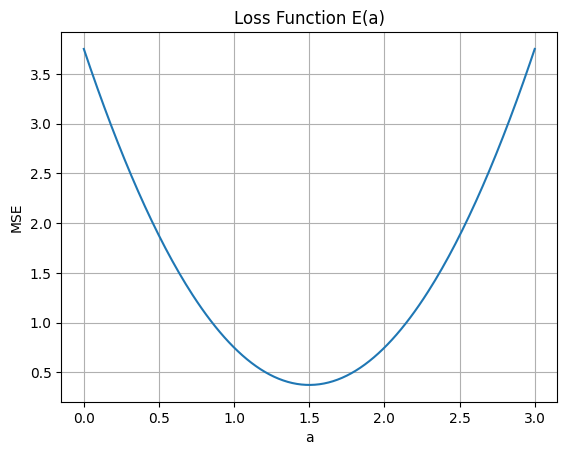

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 1, 2])
y = np.array([1, 1, 2, 3])

a_values = np.linspace(0, 3, 200)
mse_values = []

for a in a_values:
    pred = a * x
    mse = np.mean((y - pred) ** 2)
    mse_values.append(mse)

plt.plot(a_values, mse_values)
plt.xlabel("a")
plt.ylabel("MSE")
plt.title("Loss Function E(a)")
plt.grid()

plt.show()

## ***확인하기1***

- 기온 $x(℃)$ 에 따 전기차 연비 $y(km/kWh)$가 다음과 같습니다

| x(℃) | y(km/kWh) |
| ---- | --------- |
| 0    | 3         |
| 2    | 3         |
| 4    | 5         |
| 6    | 5         |

- 이 때의 추세선은 다음과 같이 정의됩니다
$$ f(x)=ax $$

## ***예측값과 오차, 오차의 제곱 구하기***
- 예측값은 $ax$ 이므로 이값과 실제값에 대해 오차를 구하고 그 제곱을 구합니다

| 입력값 (x) | 실제값 (y) | 예측값 |   오차 |        오차² |
| ------- | ------: | --: | ---: | ---------: |
| 0       |       3 |   0 |    3 |          9 |
| 2       |       3 |  2a | 3-2a | ((3-2a)^2) |
| 4       |       5 |  4a | 5-4a | ((5-4a)^2) |
| 6       |       5 |  6a | 5-6a | ((5-6a)^2) |

---

## ***손실함수 (E(a)) 구하기***

- 평균제곱오차(MSE)를 사용하면

$$ E(a) = \frac{1}{4} \left\{3^2+(3-2a)^2+(5-4a)^2+(5-6a)^2 \right\} $$

- 각 항을 전개하면

$$ (3-2a)^2=9-12a+4a^2 $$

$$ (5-4a)^2=25-40a+16a^2 $$

$$ (5-6a)^2=25-60a+36a^2 $$

- 따라서

$$ E(a) = \frac{1}{4} \left\{9+(9-12a+4a^2)+(25-40a+16a^2)+(25-60a+36a^2) \right\} $$

정리하면

$$ E(a) = \frac{1}{4} \left(68-112a+56a^2 \right) $$

- 손실함수는 다음과 같은 이차함수입니다

$$ E(a)=14a^2-28a+17 $$

---

## ***최적화된 추세선 구하기***

- 완전제곱식으로 변형하면

$$ E(a) = 14(a^2-2a)+17 $$

$$ 14\left((a-1)^2-1\right)+17 $$

$$ 14(a-1)^2+3 $$

- 이에 대한 완전제곱식은 아래와 같습니다
$$ E(a)=14(a-1)^2+3 $$

- $ (a-1)^2 $ 의 최솟값은 0이므로 $ a=1 $ 일 때 손실함수 $E(a)$가 최솟값을 가집니다
- 따라서 최적화된 추세선은 $ f(x)=x $ 입니다

---

# ***3. 미분***

---

# ***함수의 극한이란***
- 손실함수가 이차함수인 경우에는 완전제곱식을 이용하여 최솟값을 구할 수 있었습니다
- 하지만 실제 인공지능에서 사용하는 손실함수는 더욱 복잡한 형태를 가지므로 손실함수의 최솟값을 구하기 위한 일반적인 방법이 필요합니다
- 이때 사용되는 개념이 **미분** 이며, 미분을 이해하기 위해 먼저 **함수의 극한** 을 알아봅니다

---

## ***함수 $f(x)=x-1$***

함수 $f(x)=x-1$ 에서 (x)가 2에 가까워질 때 (f(x))의 값을 살펴봅니다

| x    | 1.9 | 1.99 | 1.999 | 2 | 2.001 | 2.01 | 2.1 |
| ---- | --- | ---- | ----- | - | ----- | ---- | --- |
| f(x) | 0.9 | 0.99 | 0.999 | 1 | 1.001 | 1.01 | 1.1 |

표를 보면 (x)가 2에 가까워질수록 (f(x))의 값은 1에 가까워짐을 알 수 있습니다

따라서 극한은 아래와 같이 표현됩니다
$$\lim_{x\to 2}(x-1)=1$$

---

## ***그래프로 확인하기***
- $x$가 2에 가까워질수록 그래프 위의 점은 ((2,1))에 가까워집니다
- 따라서 함수값은 1에 수렴합니다

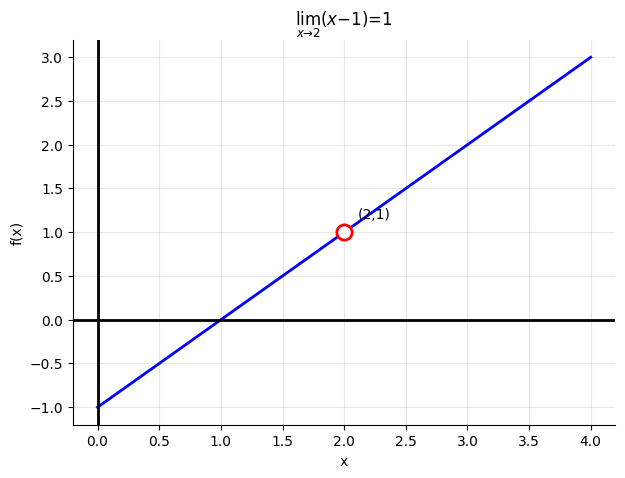

In [30]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 4, 400)
y = x - 1

fig, ax = plt.subplots(figsize=(7,5))

# 함수 그래프
ax.plot(x, y, linewidth=2, color='blue')

# 축 강조
ax.axhline(0, color='black', linewidth=2)
ax.axvline(0, color='black', linewidth=2)

# 극한 접근점
ax.scatter([2], [1],
           facecolors='white',
           edgecolors='red',
           s=120,
           linewidth=2,
           zorder=5)

ax.annotate("(2,1)", (2,1),
            textcoords="offset points",
            xytext=(10,10))

# 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 스타일
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title(r"$\lim_{x\to 2}(x-1)=1$")

ax.grid(alpha=0.3)

plt.show()

# ***함수의 극한***

일반적으로 함수 (f(x))에서

* $x$의 값이 $a$에 한없이 가까워질 때
* $f(x)$의 값이 $L$에 한없이 가까워지면

다음과 같이 표현합니다

$$
\lim_{x\to a}f(x)=L
$$

이를 **함수의 극한**이라고 합니다

---

# ***보기***

함수 $ f(x)=2x+1 $ 에서 (x)가 0에 가까워질 때를 살펴봅니다

| x    | -0.1 | -0.01 | -0.001 | 0.001 | 0.01 | 0.1 |
| ---- | ---- | ----- | ------ | ----- | ---- | --- |
| f(x) | 0.8  | 0.98  | 0.998  | 1.002 | 1.02 | 1.2 |

$x$가 0에 가까워질수록 함수값은 1에 가까워집니다

따라서 아래와 같이 표현할 수 있습니다

$$
\lim_{x\to0}(2x+1)=1
$$

이다.

---

## ***그래프로 확인하기***

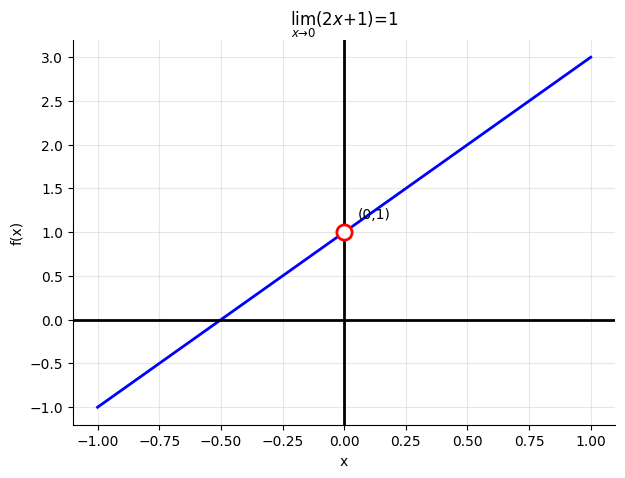

In [25]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-1, 1, 400)
y = 2*x + 1

fig, ax = plt.subplots(figsize=(7,5))

# 함수 그래프
ax.plot(x, y, linewidth=2, color='blue')

# 극한 접근점
ax.scatter([0], [1],
           facecolors='white',
           edgecolors='red',
           s=120,
           linewidth=2,
           zorder=5,
           label='limit value (0,1)')

ax.annotate("(0,1)", (0,1),
            textcoords="offset points",
            xytext=(10,10))

# 축 강조
ax.axhline(0, color='black', linewidth=2)
ax.axvline(0, color='black', linewidth=2)

# 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title(r"$\lim_{x\to0}(2x+1)=1$")

ax.grid(alpha=0.3)

plt.show()

## ***확인하기***
다음 극한값을 구합니다

$$
\lim_{x\to3}\frac{x}{3}
$$

함수 $ f(x)=\frac{x}{3} $ 에서 (x)가 3에 가까워질수록 $f(x)$ 는 $1$ 에 가까워진다.

따라서 아래와 같습니다

$$\lim_{x\to3}\frac{x}{3}=1 $$

---

### ***그래프로 확인하기***


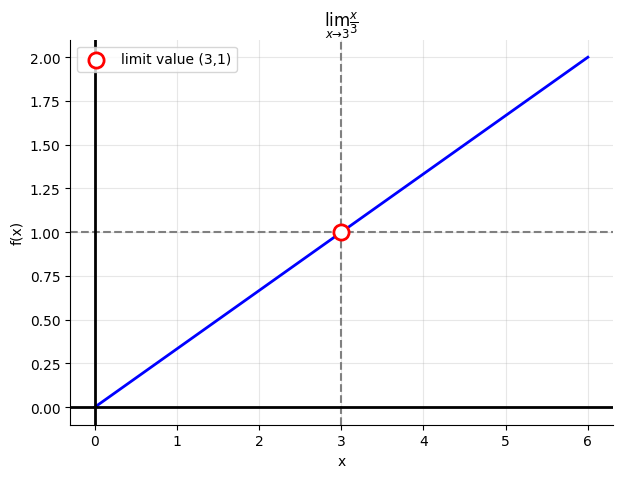

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 함수
x = np.linspace(0, 6, 400)
y = x / 3

fig, ax = plt.subplots(figsize=(7,5))

# 그래프
ax.plot(x, y, linewidth=2, color='blue')

# 극한 접근점
ax.scatter([3], [1],
           facecolors='white',
           edgecolors='red',
           s=120,
           linewidth=2,
           zorder=5,
           label='limit value (3,1)')

# 점선 보조선
ax.axvline(3, linestyle='--', color='gray')
ax.axhline(1, linestyle='--', color='gray')

ax.axhline(y=0, color='black', linewidth=2)
ax.axvline(x=0, color='black', linewidth=2)

# 축 스타일
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title(r"$\lim_{x\to3}\frac{x}{3}$")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

## ***접선의 기울기와 미분계수***
- P점에 한없이 가까이 다가가는 Q의 점을 정의하고 이에 따른 그래프의 변화를 확인해봅시다

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: x**2

x = np.linspace(-10, 10, 400)
x1 = 1
y1 = f(x1)

# 이곳을 조정하면서 좀더 구간을 잘게 쪼개어봅니다
q_list = np.linspace(5, 1, 100)[:-1]

for i, x2 in enumerate(q_list):

    y2 = f(x2)

    # 새 그림 생성
    fig, ax = plt.subplots(figsize=(7,5))

    # 함수
    ax.plot(x, f(x), color='royalblue', linewidth=2)

    # P
    ax.scatter([x1], [y1], color='red', s=100)
    ax.annotate("P", (x1, y1), xytext=(10,10), textcoords="offset points")

    # Q
    ax.scatter([x2], [y2], color='black', s=60)
    ax.annotate(f"Q{i}", (x2, y2), xytext=(10,10), textcoords="offset points")

    # secant
    m = (y2 - y1) / (x2 - x1)
    secant = m*(x - x1) + y1
    ax.plot(x, secant, '--', alpha=0.7)

    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 50)

    # 축
    ax.axhline(0, color='black', linewidth=2)
    ax.axvline(0, color='black', linewidth=2)

    ax.set_title(f"Step {i+1}")
    ax.grid(alpha=0.3)

    plt.show()

## ***예제1***
손실함수 $ E(a)=3a^2 -7a+11 $에 대하여 다음을 구합니다
- 함수 $E(a)$ 의 도함수
- 함수 $E(a)$ 의 $a=2$ 에서의 미분계수

## ***확인하기2***
- 아래 예제를 수정하여 손실함수 $E(a)=2a^2 -4a+1$ 의 도함수와 $a=3$ 에서의 미분계수를 시각화 해봅니다

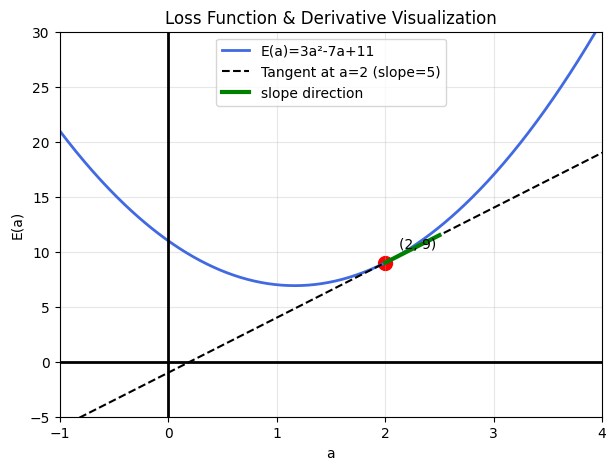

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# 손실함수
E = lambda a: 3*a**2 - 7*a + 11

# 도함수
dE = lambda a: 6*a - 7

# 범위
a = np.linspace(-1, 4, 400)

# 기준점
a0 = 2
E0 = E(a0)
slope = dE(a0)

# 접선
tangent = slope*(a - a0) + E0

fig, ax = plt.subplots(figsize=(7,5))

# 손실함수
ax.plot(a, E(a), label="E(a)=3a²-7a+11", color="royalblue", linewidth=2)

# 접선
ax.plot(a, tangent, '--', color='black', label=f"Tangent at a=2 (slope={slope})")

# 포인트
ax.scatter([a0], [E0], color='red', s=100)
ax.annotate(f"(2, {E0})", (a0, E0), xytext=(10,10), textcoords="offset points")

# 기울기 시각화 (작은 선분)
dx = 0.5
ax.plot([a0, a0+dx], [E0, E0 + slope*dx], color='green', linewidth=3, label="slope direction")

# 축
ax.axhline(0, color='black', linewidth=2)
ax.axvline(0, color='black', linewidth=2)

ax.set_xlim(-1, 4)
ax.set_ylim(-5, 30)

ax.set_title("Loss Function & Derivative Visualization")
ax.set_xlabel("a")
ax.set_ylabel("E(a)")
ax.grid(alpha=0.3)
ax.legend()

plt.show()